### **1. Introduction**

Based on the interpretation of the surrogate decision tree, sub zones are defined using simple rule based thresholds. Rather than reclustering the data, sub zones were assigned only where meaningful internal variation was identified. Here the rules are applied to label each soil sample with an interpretable sub zone.

In [1]:
import pandas as pd

df = pd.read_csv("../outputs/soil_clusters.csv")

df["sub_zone"] = "None"

mask0 = df["cluster"] == 0

df.loc[mask0 & (df["ph"] <= 5.05), "sub_zone"] = "0A_High_TAW_Acidic"
df.loc[mask0 & (df["ph"] > 5.05), "sub_zone"] = "0B_High_TAW_Favorable_pH"

df.loc[df["cluster"] == 1, "sub_zone"] = "1_Low_CEC_Acidic"
df.loc[df["cluster"] == 2, "sub_zone"] = "2_Sandy_Drought_Prone"
df.loc[df["cluster"] == 3, "sub_zone"] = "3_High_Fertility_Acidic"

df.to_csv("../outputs/soil_clusters_with_subzones.csv", index=False)

### **2. Spatial Distribution of Soil Zones in the Western Province**

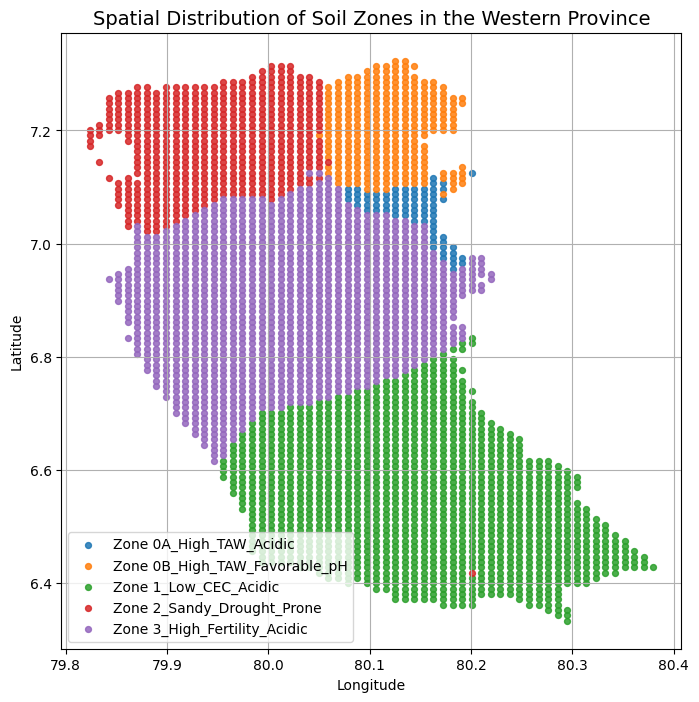

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

for c in sorted(df["sub_zone"].unique()):
    subset = df[df["sub_zone"] == c]
    plt.scatter(
        subset["lon"],
        subset["lat"],
        s=18,
        label=f"Zone {c}",
        alpha=0.85
    )

plt.title("Spatial Distribution of Soil Zones in the Western Province", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()
